# Produce Summary Plots of Experiments

In this notebook we summarize our different experiments on fine-tuning Qwen2.5-Math-1.5B on the Math dataset using SFT, EI and several versions of GRPO.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import json
import pandas as pd

colors = [plt.cm.Blues(0.8),  plt.cm.Blues(0.6),plt.cm.Blues(0.4)]
colorsR = [plt.cm.Reds(0.8),  plt.cm.Reds(0.6),plt.cm.Reds(0.4)]
%matplotlib inline

## Give a summary of the different training methods

We first compare the results of the best realizations of each of the different training methods. As a comparison metric we use the average reward on a random subset of $1024$ questions in the Math validation dataset.

In the SFT approach we trained the model with a constant learning rate of $2\cdot 10^{-5}$ for $5$ epochs on all $1404$ examples in the training set, which pass the evaluation of our grader.

The expert iteration alogrithm is also run for $5$ epochs with a constant learning rate of $2\cdot 10^{-5}$. In each epoch we choose $128$ random questions in the train set and generate $30$ rollouts for each of them. We select all rollouts which pass the grader evaluation and perform SFT with them. Here we limit ourselves to $1$ epoch of SFT in each expert iteration step.

For the GRPO algorithm we perform $100$ GRPO steps, where in each step we take a random batch of $32$ questions (groups) from the training set and generate $8$ rollouts within each group. We then maximize the GRPO objective using a clip-range of $\epsilon = 0.2$, a constant learning rate of $3\cdot 10^{-5}$ and a slightly modified advantage definition, that omits the normalization with the standard deviation, inspired by the implementation in [[5]](#-references). Below we also study several ablations and motivate why this configuration gave the best results.

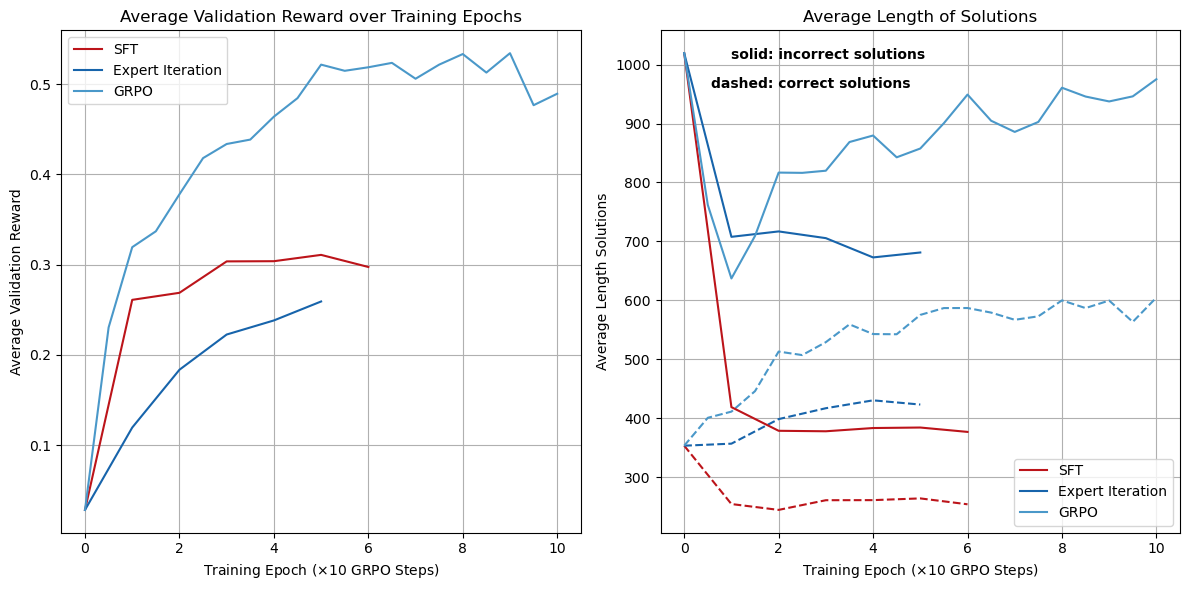

In [4]:
def load_json(file):
    with open(file, 'r') as f:
        data = json.load(f)
    return data

sft_filt = load_json('logs/sft_exp_filt/eval_log.json')
exi_128_30 = pd.read_csv('logs/exi_exp_128_30/exi_exp_128_30_data.csv')
grpo = load_json('logs/grpo_clip_wostdNorm_woLenNorm_LR_3em5/eval_log.json')
zero_shot = [sft_filt[0]['eval/reward_total']]
zero_incorrect = [sft_filt[0]['eval/incorrect_length']]
zero_correct = [sft_filt[0]['eval/correct_length']]

fig = plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)

plt.plot([sft_filt[i]['eval/reward_total'] for i in range(len(sft_filt))], label='SFT', color=colorsR[0])
plt.plot(exi_128_30['eval/reward_total'].to_numpy(),color=colors[0], label='Expert Iteration')
plt.plot(np.arange(0,10.5,0.5),zero_shot+[grpo[i]['eval/reward_total'] for i in range(len(grpo))], label='GRPO', color=colors[1])
plt.xlabel(r'Training Epoch ($\times 10$ GRPO Steps)')
plt.ylabel('Average Validation Reward')
plt.title('Average Validation Reward over Training Epochs')
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot([sft_filt[i]['eval/correct_length'] for i in range(len(sft_filt))], '--', color=colorsR[0])
plt.plot(exi_128_30['eval/correct_length'].to_numpy(), color=colors[0], ls='--')
plt.plot(np.arange(0,10.5,0.5),zero_correct+[grpo[i]['eval/correct_length'] for i in range(len(grpo))], '--', color=colors[1])
plt.plot([sft_filt[i]['eval/incorrect_length'] for i in range(len(sft_filt))], label='SFT', color=colorsR[0])
plt.plot(exi_128_30 ['eval/incorrect_length'].to_numpy(), color=colors[0], label='Expert Iteration')
plt.plot(np.arange(0,10.5,0.5),zero_incorrect+[grpo[i]['eval/incorrect_length'] for i in range(len(grpo))], label='GRPO', color=colors[1])
plt.xlabel(r'Training Epoch ($\times 10$ GRPO Steps)')
plt.ylabel('Average Length Solutions')
plt.text(1, 1010, 'solid: incorrect solutions', fontweight='bold')
plt.text(0.56, 960, 'dashed: correct solutions', fontweight='bold')
plt.title('Average Length of Solutions')
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig('./Figs/Average_Validation.png', dpi=300, bbox_inches="tight")
plt.show()

There are a few important observations that follow from our results:
1. GRPO yields by far the best results and does not require human labeled data.
2. Expert iteration can yield comparable results to SFT on carefully curated question/answer examples. In fact, if we had trained longer under the expert iteration algorithm, it might have even outperformed SFT.
3. SFT produces the shortest answers no matter if they are correct or incorrect. This might be due to the training on curated question-answer pairs which are not arbitrarily long.
4. Answer lengths generated by a model fine-tuned with GRPO grow during the training time. As long as the growth is not abnormally large, this can be seen as the model improving its reasoning capabilities and producing more detailed answers.  

## GRPO Ablations

Let us now study a few modifications of the GRPO algorithm to understand their importance for the algorithm. We will study

| Ablation | Variants | 
|----------|----------|
| Loss objective | Vanilla REINFORCE, REINFORCE with Baseline, GRPO Clip Loss |
| Advantage std normalisation | Enabled / disabled |
| Length Normalization | Normalization by output length |
| Off-policy | Several training Epochs per GRPO step |

### 1. Loss Objective

Instead of GRPO we can use a simpler algorithm, such as vanilla REINFORCE or REINFORCE with baseline. As baseline we use the advantage definition of the vanilla GRPO algorithm. These can be seen as a precursor to the more complex GRPO algorithm

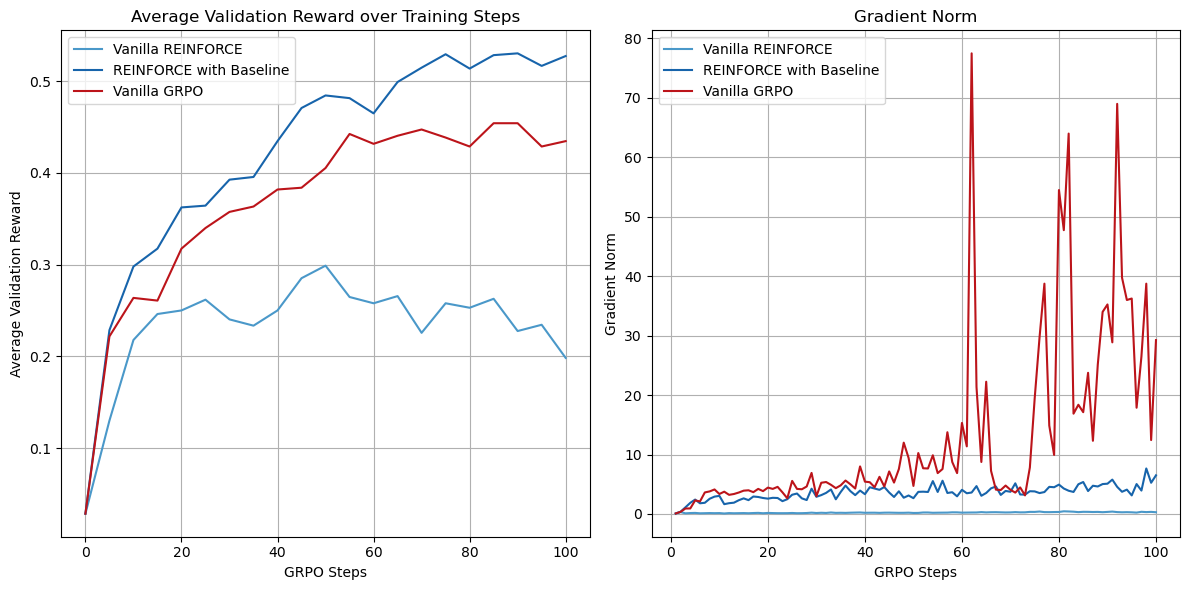

In [7]:
vanillaReinforce = load_json('logs/grpo_woBaseline_wstdNorm_woLenNorm_LR_3em5/eval_log.json')
baselineReinforce = load_json('logs/grpo_wBaseline_wstdNorm_woLenNorm_LR_3em5/eval_log.json')
vanillaGRPO = load_json('logs/grpo_clip_wstdNorm_woLenNorm_LR_3em5/eval_log.json')

vanillaGRPOGradNorm = pd.read_csv('logs/grpo_clip_wstdNorm_woLenNorm_LR_3em5/vanillaGRPO_norm.csv')['train/train_norm'].to_numpy()
baselineReinforceGradNorm = pd.read_csv('logs/grpo_wBaseline_wstdNorm_woLenNorm_LR_3em5/wBaseline_wstdNorm_woLengthNorm_gradNorm.csv')['train/train_norm'].to_numpy()
vanillaReinforceGradNorm = pd.read_csv('logs/grpo_woBaseline_wstdNorm_woLenNorm_LR_3em5/woBaseline_gradNorm.csv')['train/train_norm'].to_numpy()

fig = plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)

plt.plot(np.arange(0,101,5),zero_shot+[vanillaReinforce[i]['eval/reward_total'] for i in range(len(vanillaReinforce))], label='Vanilla REINFORCE', color=colors[1])
plt.plot(np.arange(0,101,5),zero_shot+[baselineReinforce[i]['eval/reward_total'] for i in range(len(baselineReinforce))], label='REINFORCE with Baseline', color=colors[0])
plt.plot(np.arange(0,101,5),zero_shot+[vanillaGRPO[i]['eval/reward_total'] for i in range(len(vanillaGRPO))], label='Vanilla GRPO', color=colorsR[0])
plt.xlabel(r'GRPO Steps')
plt.ylabel('Average Validation Reward')
plt.title('Average Validation Reward over Training Steps')
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(np.arange(1,101,1),vanillaReinforceGradNorm, label='Vanilla REINFORCE', color=colors[1])
plt.plot(np.arange(1,101,1),baselineReinforceGradNorm, label='REINFORCE with Baseline', color=colors[0])
plt.plot(np.arange(1,101,1),vanillaGRPOGradNorm, label='Vanilla GRPO', color=colorsR[0])
plt.xlabel(r'GRPO Steps')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norm')
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig('./Figs/Average_Validation_LossType.png', dpi=300, bbox_inches="tight")
plt.show()

This clearly shows that using a baseline significantly improves training performance (left plot). One of the reasons is that without baseline the model only learns from correct answers, since only those get a non-zero reward. However, when a baseline is used, incorrect answers get an effectively negative reward and we do a gradient step in the opposite direction. This is clearly visible in the gradient norms (right plot), where vanilla REINFORCE has significantly smaller gradient updates.

REINFORCE with Baseline and vanilla GRPO are almost identical for short GRPO steps with few training examples, since the model barely changes and GRPO is effectively on-policy the whole time. The difference in accuracy seen above could be a statistical fluctuation or it might show that the loss using logs in the REINFORCE objective is more stable than probability ratios in GRPO. This is also supported by the gradient norms during training (right plot) which is significantly noisier for GRPO.

### 2. Advantage Standard Normalization

In the Dr. GRPO paper it was pointed out that the normalization with the standard deviation in the GRPO advantage definition introduces a bias towards easy and difficult problems, since in those cases the standard deviation will be small (almost all or almost no answers are correct), what boosts the advantage for those examples. Here we check how this affects the training.

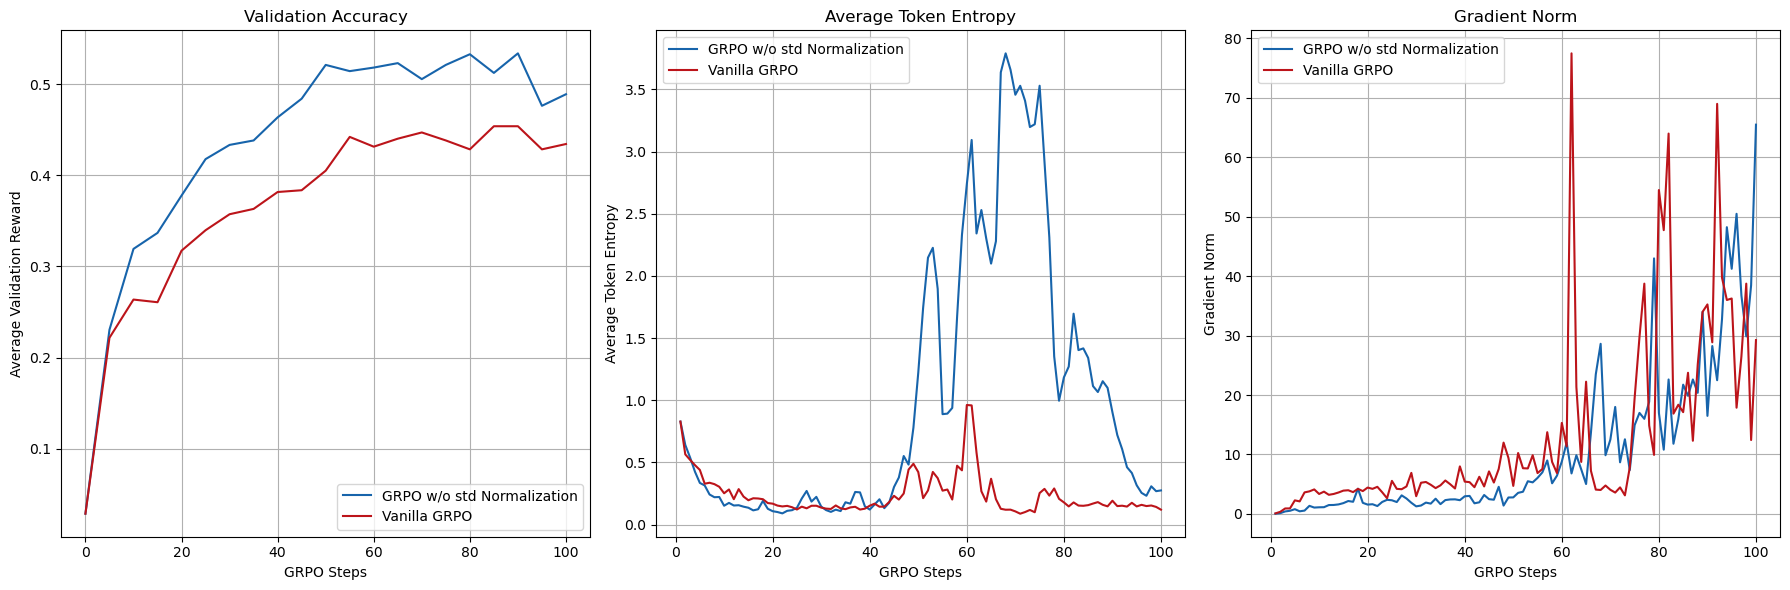

In [27]:
nostdNormGRPO = load_json('logs/grpo_clip_wostdNorm_woLenNorm_LR_3em5/eval_log.json')
vanillaGRPO = load_json('logs/grpo_clip_wstdNorm_woLenNorm_LR_3em5/eval_log.json')

vanillaGRPOTokenEnt = load_json('logs/grpo_clip_wstdNorm_woLenNorm_LR_3em5/train_token_ent_log.json')
nostdNormGRPOTokenEnt = load_json('logs/grpo_clip_wostdNorm_woLenNorm_LR_3em5/train_token_ent_log.json')

vanillaGRPOGradNorm = pd.read_csv('logs/grpo_clip_wstdNorm_woLenNorm_LR_3em5/vanillaGRPO_norm.csv')['train/train_norm'].to_numpy()
nostdNormGRPOGradNorm = pd.read_csv('logs/grpo_clip_wostdNorm_woLenNorm_LR_3em5/nostdNormGRPO_norm.csv')['train/train_norm'].to_numpy()

fig = plt.figure(figsize=(18, 6))
plt.subplot(1,3,1)
plt.plot(np.arange(0,101,5),zero_shot+[nostdNormGRPO[i]['eval/reward_total'] for i in range(len(nostdNormGRPO))], label='GRPO w/o std Normalization', color=colors[0])
plt.plot(np.arange(0,101,5),zero_shot+[vanillaGRPO[i]['eval/reward_total'] for i in range(len(vanillaGRPO))], label='Vanilla GRPO', color=colorsR[0])
plt.xlabel(r'GRPO Steps')
plt.ylabel('Average Validation Reward')
plt.title('Validation Accuracy')
plt.grid(True)
plt.legend()

plt.subplot(1,3,2)
plt.plot(np.arange(1,101,1),nostdNormGRPOTokenEnt, label='GRPO w/o std Normalization', color=colors[0])
plt.plot(np.arange(1,101,1),vanillaGRPOTokenEnt, label='Vanilla GRPO', color=colorsR[0])
plt.xlabel(r'GRPO Steps')
plt.ylabel('Average Token Entropy')
plt.title('Average Token Entropy')
plt.grid(True)
plt.legend()

plt.subplot(1,3,3)
plt.plot(np.arange(1,101,1),nostdNormGRPOGradNorm, label='GRPO w/o std Normalization', color=colors[0])
plt.plot(np.arange(1,101,1),vanillaGRPOGradNorm, label='Vanilla GRPO', color=colorsR[0])
plt.xlabel(r'GRPO Steps')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norm')
plt.grid(True)
plt.legend()
plt.savefig('./Figs/StdAvantage_Ablation.png', dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

Removing the standard deviation as normalization indeed improves the performance considerably. In order to figure out why that is, it is worth checking some training metrics.

These plots give a hint why removing the standard deviation in the advantage definition might improve training performance. The plot of the gradient norm shows that vanilla GRPO is slightly less stable with a consistently larger gradient norm and many large spikes in the later phases of training. Even though we clip gradients at a norm of $1.0$, this indicates that training is less stable with vanilla GRPO.

Another intersting metric is the average token entropy of the language model rollouts. A larger entropy signals that the model is less certain about its output, what is to some extent needed during training, since it favors exploration over exploitation. Removing the normalization allows the model to explore more during training, what can boost training performance.

### 3. Length Normalization

In the previous studies we have constructed the loss by using the average loss per token in each rollout. However, it is also possible to take the sum and normalize by the longest answer length. The comparison of vanilla GRPO and this ablation is shown below.

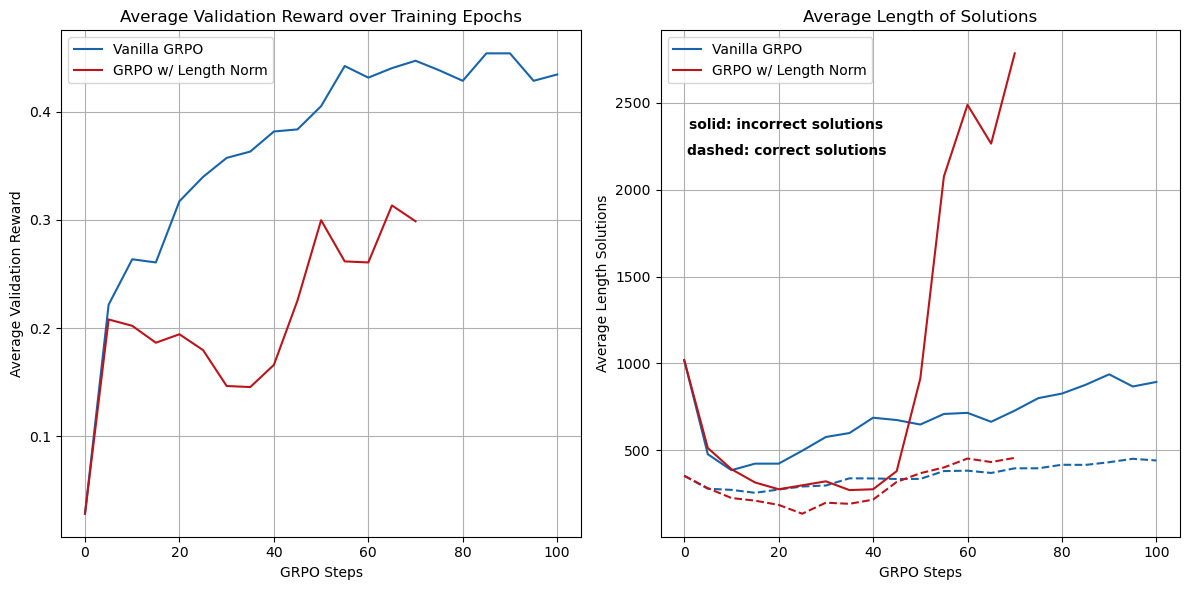

In [13]:
vanillaGRPO = load_json('logs/grpo_clip_wstdNorm_woLenNorm_LR_3em5/eval_log.json')

GRPOLenNorm = pd.read_csv('logs/grpo_clip_wstdNorm_wLenNorm_LR_3em5/grpo_clip_wstdNorm_wLenNorm.csv')

fig = plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)

plt.plot(np.arange(0,101,5),zero_shot+[vanillaGRPO[i]['eval/reward_total'] for i in range(len(grpo))], label='Vanilla GRPO', color=colors[0])
plt.plot(np.arange(0,101,5)[:len(GRPOLenNorm['eval/reward_total'].to_list())+1],zero_shot+GRPOLenNorm['eval/reward_total'].to_list(), label='GRPO w/ Length Norm', color=colorsR[0])
plt.xlabel(r'GRPO Steps')
plt.ylabel('Average Validation Reward')
plt.title('Average Validation Reward over Training Epochs')
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(np.arange(0,101,5),zero_correct+[vanillaGRPO[i]['eval/correct_length'] for i in range(len(grpo))], '--', color=colors[0])
plt.plot(np.arange(0,101,5),zero_incorrect+[vanillaGRPO[i]['eval/incorrect_length'] for i in range(len(grpo))], '-', color=colors[0], label='Vanilla GRPO')
plt.plot(np.arange(0,101,5)[:len(GRPOLenNorm['eval/correct_length'].to_list())+1],zero_correct+GRPOLenNorm['eval/correct_length'].to_list(), '--', color=colorsR[0])
plt.plot(np.arange(0,101,5)[:len(GRPOLenNorm['eval/incorrect_length'].to_list())+1],zero_incorrect+GRPOLenNorm['eval/incorrect_length'].to_list(), '-', label='GRPO w/ Length Norm', color=colorsR[0])
plt.xlabel(r'GRPO Steps')
plt.ylabel('Average Length Solutions')
plt.text(1, 2350, 'solid: incorrect solutions', fontweight='bold')
plt.text(0.56, 2200, 'dashed: correct solutions', fontweight='bold')
plt.title('Average Length of Solutions')
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig('./Figs/Length_Normalization.png', dpi=300, bbox_inches="tight")
plt.show()

The training with length normalization is less stable than vanilla GRPO, what is mainly due to the exploding length of incorrect model answers (right plot). Length normalization allows the model to reduce the loss for incorrect answers by making them longer.

### 4. Off-Policy

The clipping prescription makes it possible to run GRPO off-policy. Here we test the performance of an algorithm which goes through 2 epochs of training in each GRPO stop.

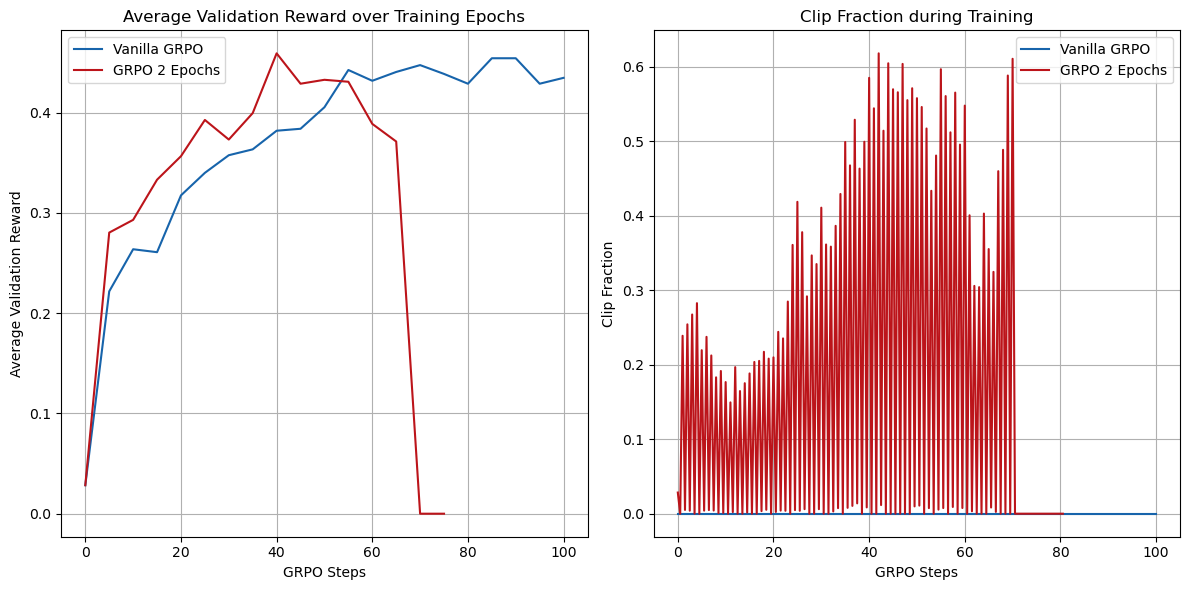

In [14]:
vanillaGRPO = load_json('logs/grpo_clip_wstdNorm_woLenNorm_LR_3em5/eval_log.json')

GRPOL2epoch_eval = pd.read_csv('logs/grpo_clip_wstdNorm_woLenNorm_2epoch_LR_3em5/grpo_2epochs_eval.csv')
GRPOL2epoch_train = pd.read_csv('logs/grpo_clip_wstdNorm_woLenNorm_2epoch_LR_3em5/grpo_2epochs_train.csv')

fig = plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)

plt.plot(np.arange(0,101,5),zero_shot+[vanillaGRPO[i]['eval/reward_total'] for i in range(len(grpo))], label='Vanilla GRPO', color=colors[0])
plt.plot(np.arange(0,101,5)[:len(GRPOL2epoch_eval['eval/reward_total'].to_list())+1],zero_shot+GRPOL2epoch_eval['eval/reward_total'].to_list(), label='GRPO 2 Epochs', color=colorsR[0])
plt.xlabel(r'GRPO Steps')
plt.ylabel('Average Validation Reward')
plt.title('Average Validation Reward over Training Epochs')
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(np.arange(0,101,5),[0. for i in range(0,101,5)], label='Vanilla GRPO', color=colors[0])
plt.plot(np.arange(0,101,0.5)[:len(GRPOL2epoch_train['train/clip_fraction'].to_list())+1],zero_shot+GRPOL2epoch_train['train/clip_fraction'].to_list(), label='GRPO 2 Epochs', color=colorsR[0])
plt.xlabel(r'GRPO Steps')
plt.ylabel('Clip Fraction')
plt.title('Clip Fraction during Training')
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig('./Figs/OffPolicy.png', dpi=300, bbox_inches="tight")
plt.show()

At first the off-policy algorithm trains well with a relatively low clipping fraction (see right plot). The clipping fraction refers to the fraction of token losses which are clipped in the GRPO algorithm. However, as training progresses the clipping fraction increases until eventually the algorithm becomes unstable and the language model undergoes catastrophic forgetting. Nonetheless, the results look promising and a further tuning of hyperparameters could make the algorithm more stable.